In [4]:
import numpy as np                     # array math
import pandas as pd                    # tables & dates
import xarray as xr                    # read/handle .nc files (main tool)
import netCDF4                         # .nc reader engine 
import scipy.stats as stats            # stats: distributions, percentiles

import geopandas as gpd                # shapefiles (note: gpd, not pd!)
import rioxarray                       # CRS, clipping, resolution
import regionmask                      # mask by country/region

import matplotlib.pyplot as plt        # make plots
import cartopy.crs as ccrs             # map projections
import cartopy.feature as cfeature     # coastlines, borders
from matplotlib.colors import BoundaryNorm

import metpy.calc as mpcalc            # weather math
from metpy.plots import ContourPlot, ImagePlot, MapPanel, PanelContainer  # quick maps
from metpy.units import units          # attach units (mm, K…)
from datetime import datetime          # dates
import cftime                          # odd climate calendars
import glob


In [24]:
files = sorted(glob.glob("/g/data/zv2/agcd/v2-0-3/precip/total/r005/01month/agcd_v2_precip_total_r005_monthly_*.nc"))
files = [f for f in files if 1939 <= int(f.split("_")[-1][:4]) <= 2023]
#print(files)  # always check you got the right 

print("Number of files:", len(files))

ds = xr.open_mfdataset(files, combine="by_coords") #puting nc file in ds variable
print(ds) #to know name of the precipitation data


Number of files: 85


/jobfs/171416528.gadi-pbs/ipykernel_3032259/1920955311.py:7: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(files, combine="by_coords") #puting nc file in ds variable


<xarray.Dataset> Size: 3GB
Dimensions:    (time: 1020, lat: 691, nv: 2, lon: 886)
Coordinates:
  * time       (time) datetime64[ns] 8kB 1939-01-16 ... 2023-12-16
  * lat        (lat) float32 3kB -44.5 -44.45 -44.4 ... -10.1 -10.05 -10.0
  * lon        (lon) float32 4kB 112.0 112.1 112.1 112.2 ... 156.1 156.2 156.2
Dimensions without coordinates: nv
Data variables:
    lat_bnds   (time, lat, nv) float32 6MB dask.array<chunksize=(12, 691, 2), meta=np.ndarray>
    lon_bnds   (time, lon, nv) float32 7MB dask.array<chunksize=(12, 886, 2), meta=np.ndarray>
    time_bnds  (time, nv) datetime64[ns] 16kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    precip     (time, lat, lon) float32 2GB dask.array<chunksize=(1, 691, 886), meta=np.ndarray>
    crs        (time) int32 4kB -2147483647 -2147483647 ... -2147483647
Attributes: (12/33)
    geospatial_lat_min:        -44.525
    geospatial_lat_max:        -9.975
    geospatial_lon_min:        111.975
    geospatial_lon_max:        156.275
    tim

In [47]:
# Put precipitation values into the variable called rain
rain = ds["precip"]
#print(rain)
# Rechunk the data so the full 1020 month time dimension is in one chunk.
# This allows the 12-month rolling window to see enough months at once.
rain = rain.chunk({"time": -1, "lat": -1, "lon": -1})

# Check the new chunk structure
print(rain.chunks)

# Calculate 12-month moving average at every grid cell
rain_12m = rain.rolling(time=12, min_periods=12).mean()

# Select a small sample for checking
rain_12m_sample = rain_12m.isel(lat=25, lon=25)

# Convert the small gridded sample to a table
rain_12m_table = rain_12m_sample.compute().to_dataframe(name="rain_12m").reset_index()

# Display the table
print(rain_12m_table)

((1020,), (691,), (886,))
                    time    lat     lon    rain_12m
0    1939-01-16 00:00:00 -43.25  113.25         NaN
1    1939-02-14 12:00:00 -43.25  113.25         NaN
2    1939-03-16 00:00:00 -43.25  113.25         NaN
3    1939-04-15 12:00:00 -43.25  113.25         NaN
4    1939-05-16 00:00:00 -43.25  113.25         NaN
...                  ...    ...     ...         ...
1015 2023-08-16 00:00:00 -43.25  113.25  189.399994
1016 2023-09-15 12:00:00 -43.25  113.25  189.399994
1017 2023-10-16 00:00:00 -43.25  113.25  189.399994
1018 2023-11-15 12:00:00 -43.25  113.25  189.399994
1019 2023-12-16 00:00:00 -43.25  113.25  189.399994

[1020 rows x 4 columns]


In [48]:
rain_sample = rain.isel(lat=25, lon=25).compute().to_dataframe(name="raw_precip").reset_index()
print(rain_sample[rain_sample['time'].dt.year == 2023].to_string(index=False))

               time    lat    lon  raw_precip
2023-01-16 00:00:00 -43.25 113.25   23.635742
2023-02-14 12:00:00 -43.25 113.25   10.958008
2023-03-16 00:00:00 -43.25 113.25   66.800781
2023-04-15 12:00:00 -43.25 113.25  136.229492
2023-05-16 00:00:00 -43.25 113.25  298.946289
2023-06-15 12:00:00 -43.25 113.25  397.230469
2023-07-16 00:00:00 -43.25 113.25  425.688477
2023-08-16 00:00:00 -43.25 113.25  361.944336
2023-09-15 12:00:00 -43.25 113.25  255.532227
2023-10-16 00:00:00 -43.25 113.25  159.197266
2023-11-15 12:00:00 -43.25 113.25   99.888672
2023-12-16 00:00:00 -43.25 113.25   36.748047


In [33]:
one_cell_raw = rain.sel(lat=-40.0, lon=148.0, method="nearest")
one_cell_12m = rain_12m.sel(lat=-40.0, lon=148.0, method="nearest")

one_cell_check = pd.DataFrame({
    "raw_monthly_rainfall": one_cell_raw.compute().to_series(),
    "rain_12m_moving_average": one_cell_12m.compute().to_series()
})

print(one_cell_check.loc["1945"]) #Checking monthly and moving average for 1941

# Calculate the 25th percentile of the 12-month moving average values.
# We use dropna() because the first 11 months are NaN.
p25_one_grid_1945_only = one_cell_check.loc["1945", "rain_12m_moving_average"].dropna().quantile(0.25)
p25_one_grid = one_cell_check["rain_12m_moving_average"].dropna().quantile(0.25)

print("25th percentile threshold (1 year check):", p25_one_grid_1945_only) # This is 25th percentile using 1945 data only
print("25th percentile threshold:", p25_one_grid)

                     raw_monthly_rainfall  rain_12m_moving_average
time                                                              
1945-01-16 00:00:00             42.712891                49.602459
1945-02-14 12:00:00            116.289062                58.405437
1945-03-16 00:00:00             28.881836                57.280113
1945-04-15 12:00:00             28.739258                53.873535
1945-05-16 00:00:00             46.334961                48.607830
1945-06-15 12:00:00             50.209961                49.677979
1945-07-16 00:00:00             28.991211                47.513592
1945-08-16 00:00:00            109.159180                53.306969
1945-09-15 12:00:00             54.852539                55.101562
1945-10-16 00:00:00             71.006836                58.625244
1945-11-15 12:00:00             33.291992                58.013592
1945-12-16 00:00:00              7.117188                51.465576
25th percentile threshold (1 year check): 49.659098625183105
2

In [34]:
#Calculate 25th percentile for every grid cell
p25 = rain_12m.quantile(0.25, dim="time", skipna=True)
print(p25)

<xarray.DataArray 'precip' (lat: 691, lon: 886)> Size: 5MB
dask.array<getitem, shape=(691, 886), dtype=float64, chunksize=(691, 886), chunktype=numpy.ndarray>
Coordinates:
  * lat       (lat) float32 3kB -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon       (lon) float32 4kB 112.0 112.1 112.1 112.2 ... 156.1 156.2 156.2
    quantile  float64 8B 0.25
Attributes:
    cell_methods:           time: sum time: sum (interval : 1 day)
    units:                  mm
    long_name:              Daily precipitation
    standard_name:          lwe_thickness_of_precipitation_amount
    frequency:              monthly
    start_offset:           -24
    grid_mapping:           crs
    coverage_content_type:  physicalMeasurement
    valid_range:            [     0. 100000.]


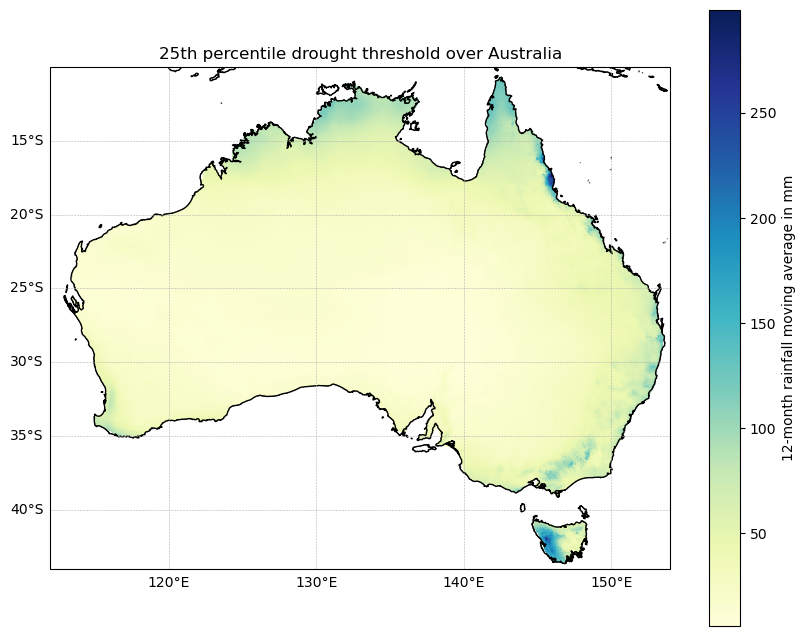

In [58]:
#Plot of the 25th Percentile value 
p25 = p25.squeeze(drop=True)

# Mask to Australia only
mask = regionmask.defined_regions.natural_earth_v5_0_0.countries_110.mask(p25.lon, p25.lat)
p25_masked = p25.where(mask == 137)  # 137 is Australia's index

# Create map figure using PlateCarree projection.
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot the 25th percentile rainfall threshold
p25_masked.plot(
    ax=ax,
    x="lon",
    y="lat",
    transform=ccrs.PlateCarree(),
    cmap="YlGnBu",
    cbar_kwargs={"label": "12-month rainfall moving average in mm"}
)
# Add Australian coastline
ax.coastlines(resolution="10m", linewidth=1.0, color="black")
# Add country borders
ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor="black")
# Add land outline lightly
ax.add_feature(cfeature.LAND, facecolor="none", edgecolor="black", linewidth=0.5)
# Zoom to Australia
ax.set_extent([112, 154, -44, -10], crs=ccrs.PlateCarree())
# Add longitude/latitude gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.4, linestyle="--")
gl.top_labels = False
gl.right_labels = False
ax.set_title("25th percentile drought threshold over Australia")
plt.show()

In [40]:
#Checking drought occurence for 1945
rain_12m_1945 = rain_12m.sel(time=slice("1945", "1945"))

# Select only May to October from 1941.
# Month numbers:
# May = 5
# June = 6
# July = 7
# August = 8
# September = 9
# October = 10

rain_12m_1945_may_oct = rain_12m.sel(time=slice("1945-05", "1945-10"))

# Defining drought

drought_1945_may_oct = rain_12m_1945_may_oct < p25

drought_count_1945_may_oct = drought_1945_may_oct.sum(dim="time", skipna=True)

drought_percent_1945_may_oct = (drought_count_1945_may_oct / 6) * 100

drought_percent_1945_may_oct


<xarray.DataArray 'precip' (lat: 691, lon: 886)> Size: 5MB
dask.array<mul, shape=(691, 886), dtype=float64, chunksize=(691, 886), chunktype=numpy.ndarray>
Coordinates:
  * lat       (lat) float32 3kB -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon       (lon) float32 4kB 112.0 112.1 112.1 112.2 ... 156.1 156.2 156.2
    quantile  float64 8B 0.25
Attributes:
    cell_methods:           time: sum time: sum (interval : 1 day)
    units:                  mm
    long_name:              Daily precipitation
    standard_name:          lwe_thickness_of_precipitation_amount
    frequency:              monthly
    start_offset:           -24
    grid_mapping:           crs
    coverage_content_type:  physicalMeasurement
    valid_range:            [     0. 100000.]

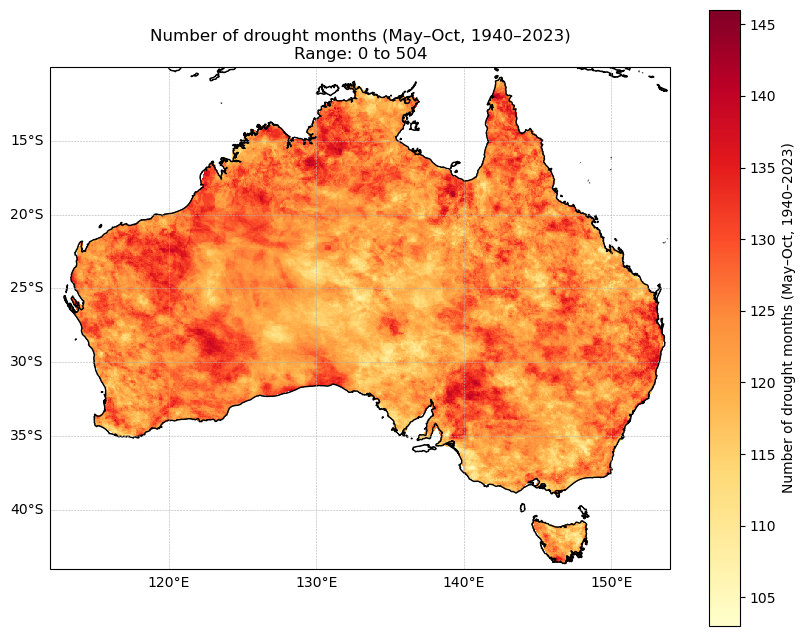

Total possible months per grid: 504
Max drought count any grid:     146
Min drought count any grid:     0


In [60]:
# Select May–Oct across ALL years (1940–2023)
rain_12m_may_oct = rain_12m.sel(time=rain_12m.time.dt.month.isin([5, 6, 7, 8, 9, 10]))
rain_12m_may_oct = rain_12m_may_oct.sel(time=slice("1940", "2023"))

# Defining drought
drought_may_oct = rain_12m_may_oct < p25

# Count drought months per grid cell (0 to 504)
drought_count = drought_may_oct.sum(dim="time", skipna=True)

# Mask to Australia
mask = regionmask.defined_regions.natural_earth_v5_0_0.countries_110.mask(drought_count.lon, drought_count.lat)
drought_count_masked = drought_count.where(mask == 137)

# Plot
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

drought_count_masked.plot(
    ax=ax,
    x="lon",
    y="lat",
    transform=ccrs.PlateCarree(),
    cmap="YlOrRd",
    cbar_kwargs={"label": "Number of drought months (May–Oct, 1940–2023)"}
)

ax.coastlines(resolution="10m", linewidth=1.0, color="black")
ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor="black")
ax.add_feature(cfeature.LAND, facecolor="none", edgecolor="black", linewidth=0.5)
ax.set_extent([112, 154, -44, -10], crs=ccrs.PlateCarree())

gl = ax.gridlines(draw_labels=True, linewidth=0.4, linestyle="--")
gl.top_labels = False
gl.right_labels = False

ax.set_title("Number of drought months (May–Oct, 1940–2023)\nRange: 0 to 504")
plt.show()

# Sanity check
print(f"Total possible months per grid: {len(rain_12m_may_oct.time)}")
print(f"Max drought count any grid:     {int(drought_count.max().values)}")
print(f"Min drought count any grid:     {int(drought_count.min().values)}")

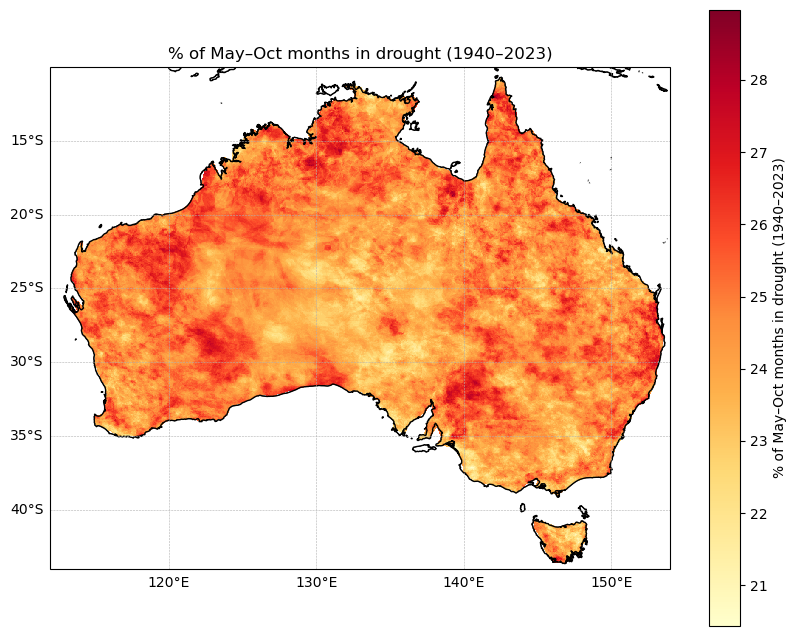

Total months used: 504
Max drought count: 146
Min drought count: 0


In [59]:
# Select May–Oct across ALL years (1940–2023)
rain_12m_may_oct = rain_12m.sel(time=rain_12m.time.dt.month.isin([5, 6, 7, 8, 9, 10]))
rain_12m_may_oct = rain_12m_may_oct.sel(time=slice("1940", "2023"))

# Defining drought
drought_may_oct = rain_12m_may_oct < p25

# Count drought months per grid cell (0 to 504)
drought_count = drought_may_oct.sum(dim="time", skipna=True)

# Convert to percentage (out of 504 total months)
total_months = len(rain_12m_may_oct.time)  # 84 years × 6 = 504
drought_percent = (drought_count / total_months) * 100

# Mask to Australia
mask = regionmask.defined_regions.natural_earth_v5_0_0.countries_110.mask(drought_percent.lon, drought_percent.lat)
drought_percent_masked = drought_percent.where(mask == 137)

# Plot
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

drought_percent_masked.plot(
    ax=ax,
    x="lon",
    y="lat",
    transform=ccrs.PlateCarree(),
    cmap="YlOrRd",
    cbar_kwargs={"label": "% of May–Oct months in drought (1940–2023)"}
)

ax.coastlines(resolution="10m", linewidth=1.0, color="black")
ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor="black")
ax.add_feature(cfeature.LAND, facecolor="none", edgecolor="black", linewidth=0.5)
ax.set_extent([112, 154, -44, -10], crs=ccrs.PlateCarree())

gl = ax.gridlines(draw_labels=True, linewidth=0.4, linestyle="--")
gl.top_labels = False
gl.right_labels = False

ax.set_title("% of May–Oct months in drought (1940–2023)")
plt.show()

# Quick sanity check
print(f"Total months used: {total_months}")
print(f"Max drought count: {int(drought_count.max().values)}")
print(f"Min drought count: {int(drought_count.min().values)}")

In [44]:
# Select May–Oct across ALL years (1940–2023)
rain_12m_may_oct = rain_12m.sel(
    time=rain_12m.time.dt.month.isin([5, 6, 7, 8, 9, 10])
)

print(pd.DatetimeIndex(rain_12m_may_oct.time.values).month_name().value_counts().to_frame())

# Pick one lat/lon point and show a small slice as a table
sample = rain_12m_may_oct.isel(lat=0, lon=0).to_dataframe().reset_index()
print(sample[['time', 'precip']].head(20).to_string(index=False))  # replace 'precip' with your actual variable name

           count
May           85
June          85
July          85
August        85
September     85
October       85
               time     precip
1939-05-16 00:00:00        NaN
1939-06-15 12:00:00        NaN
1939-07-16 00:00:00        NaN
1939-08-16 00:00:00        NaN
1939-09-15 12:00:00        NaN
1939-10-16 00:00:00        NaN
1940-05-16 00:00:00 202.687988
1940-06-15 12:00:00 202.687988
1940-07-16 00:00:00 202.687988
1940-08-16 00:00:00 202.687988
1940-09-15 12:00:00 202.687988
1940-10-16 00:00:00 202.687988
1941-05-16 00:00:00 202.687988
1941-06-15 12:00:00 202.687988
1941-07-16 00:00:00 202.687988
1941-08-16 00:00:00 202.687988
1941-09-15 12:00:00 202.687988
1941-10-16 00:00:00 202.687988
1942-05-16 00:00:00 202.687988
1942-06-15 12:00:00 202.687988


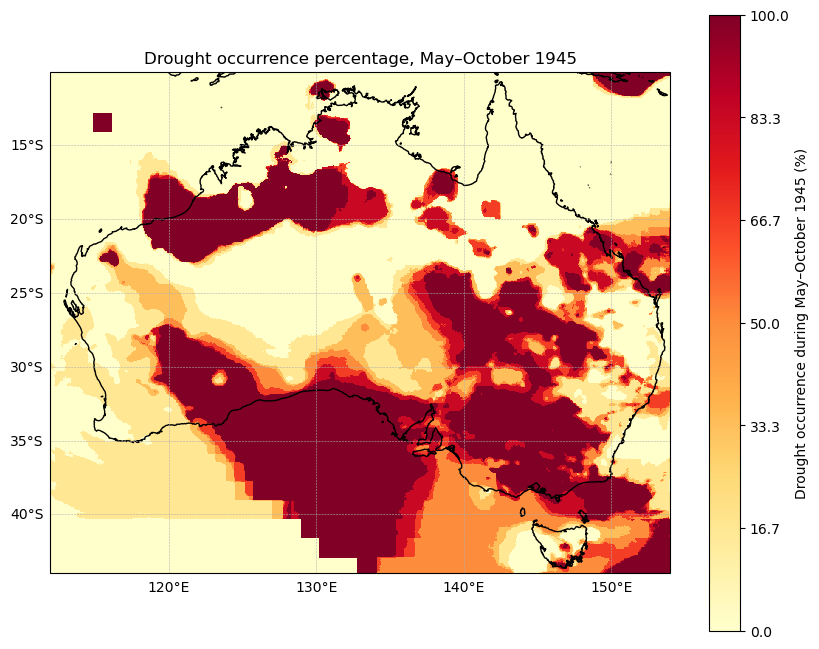

In [39]:
# Make sure drought_percent_1901_may_oct is 2D: lat x lon
drought_percent_1945_may_oct = drought_percent_1945_may_oct.squeeze(drop=True)

# Create map figure using PlateCarree projection.
# PlateCarree is suitable because the data uses normal longitude/latitude coordinates.
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot drought percentage.
# Each grid cell shows the percentage of May–October months that were drought months.
#
# Since May–October has 6 months:
# 0%      = 0 drought months
# 16.67%  = 1 drought month
# 33.33%  = 2 drought months
# 50%     = 3 drought months
# 66.67%  = 4 drought months
# 83.33%  = 5 drought months
# 100%    = 6 drought months
drought_percent_1945_may_oct.plot(
    ax=ax,
    x="lon",
    y="lat",
    transform=ccrs.PlateCarree(),
    cmap="YlOrRd",
    vmin=0,
    vmax=100,
    cbar_kwargs={
        "label": "Drought occurrence during May–October 1945 (%)",
        "ticks": [0, 16.67, 33.33, 50, 66.67, 83.33, 100]
    }
)

# Add Australian coastline
ax.coastlines(resolution="10m", linewidth=1.0, color="black")

# Add country borders
ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor="black")

# Add land outline lightly
ax.add_feature(cfeature.LAND, facecolor="none", edgecolor="black", linewidth=0.5)

# Zoom to Australia and Tasmania
ax.set_extent([112, 154, -44, -10], crs=ccrs.PlateCarree())

# Add longitude/latitude gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.4, linestyle="--")
gl.top_labels = False
gl.right_labels = False

# Add title
ax.set_title("Drought occurrence percentage, May–October 1945")

# Show plot
plt.show()

In [12]:
# Convert drought percentage map to table.
# Each row is one grid cell.
#
# drought_percent means:
# percentage of May–October months that were drought months.

drought_percent_1901_table = drought_percent_1901_may_oct.compute().to_dataframe(
    name="drought_percent"
).reset_index()

# Summarise how many grid cells had each drought percentage.

drought_percent_summary = drought_percent_1901_table[
    "drought_percent"
].value_counts().sort_index()

print(drought_percent_summary)

# Keep only grid cells where drought percentage is greater than 0.
# These are grid cells that had drought at least once during May–October 1901.

drought_cells_1901 = drought_percent_1901_table[
    drought_percent_1901_table["drought_percent"] > 0
]

drought_cells_1901

drought_percent
0.000000      344649
16.666667      50556
33.333333      37893
50.000000      35286
66.666667      24324
83.333333      26188
100.000000     29490
116.666667     34345
133.333333     29495
Name: count, dtype: int64


,lat,lon,quantile,drought_percent
494,-44.5,136.699997,0.25,16.666667
495,-44.5,136.750000,0.25,16.666667
496,-44.5,136.800003,0.25,16.666667
497,-44.5,136.850006,0.25,16.666667
498,-44.5,136.899994,0.25,16.666667
...,...,...,...,...
611695,-10.0,129.750000,0.25,33.333333
611696,-10.0,129.800003,0.25,33.333333
611697,-10.0,129.850006,0.25,33.333333
611698,-10.0,129.899994,0.25,16.666667


In [11]:
# Checking drought occurrence for 1941 to 1945
rain_12m_1941 = rain_12m.sel(time=slice("191", "1945"))

# Select only May to October from 1941 to 1945.
# Month numbers:
# May = 5
# June = 6
# July = 7
# August = 8
# September = 9
# October = 10

rain_12m_1941_may_oct = rain_12m_1941.where(
    rain_12m_1941["time.month"].isin([5, 6, 7, 8, 9, 10]),
    drop=True
)

# Defining drought

p25 = p25.squeeze(drop=True)

drought_1941_may_oct = rain_12m_1941_may_oct < p25

drought_count_1941_may_oct = drought_1941_may_oct.sum(dim="time", skipna=True)

drought_count_1941_may_oct

drought_count_1941_table = drought_count_1941_may_oct.compute().to_dataframe(
    name="drought_count"
).reset_index()

# Count how many grid cells had 0, 1, 2, ..., 30 drought months
# because 1941 to 1945 = 5 years
# May to October = 6 months each year
# 5 x 6 = 30 possible drought months

drought_count_summary = drought_count_1941_table["drought_count"].value_counts().sort_index()

print(drought_count_summary)

TypeError: cannot do slice indexing on DatetimeIndex with these indexers [191] of type str

In [ ]:
da = ds["precip"]
print(da)


In [ ]:
WINDOW = 12   # annual definition: this month + the 11 months before it

In [ ]:
# Check 1 — what frequency does the file itself claim?
print(ds.attrs.get("frequency"))           # often says 'monthly' or 'daily'
print(ds["precip"].attrs.get("cell_methods"))   # e.g. 'time: sum' / mentions month

In [ ]:
# Check 2 — the decisive test: how far apart are consecutive time steps?
print(ds["time"].values[:5])               # first few dates
import numpy as np
gaps = np.diff(ds["time"].values)          # spacing between steps
print(gaps[:5])